In [386]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                             recall_score, f1_score, classification_report)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from typing import List, Any
import warnings
warnings.filterwarnings('ignore')

In [387]:
# options
pd.set_option('display.max_columns', None)

In [388]:
df = pd.read_csv('churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [389]:
df.shape

(7043, 21)

In [390]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [391]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [392]:
print('Unique values for column: ')
for col in df.drop(['customerID', 'SeniorCitizen', 'tenure', 'MonthlyCharges'], axis=1).columns:
    print(f"  - {col}: {df[col].unique()}")

Unique values for column: 
  - gender: ['Female' 'Male']
  - Partner: ['Yes' 'No']
  - Dependents: ['No' 'Yes']
  - PhoneService: ['No' 'Yes']
  - MultipleLines: ['No phone service' 'No' 'Yes']
  - InternetService: ['DSL' 'Fiber optic' 'No']
  - OnlineSecurity: ['No' 'Yes' 'No internet service']
  - OnlineBackup: ['Yes' 'No' 'No internet service']
  - DeviceProtection: ['No' 'Yes' 'No internet service']
  - TechSupport: ['No' 'Yes' 'No internet service']
  - StreamingTV: ['No' 'Yes' 'No internet service']
  - StreamingMovies: ['No' 'Yes' 'No internet service']
  - Contract: ['Month-to-month' 'One year' 'Two year']
  - PaperlessBilling: ['Yes' 'No']
  - PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
  - TotalCharges: ['29.85' '1889.5' '108.15' ... '346.45' '306.6' '6844.5']
  - Churn: ['No' 'Yes']


Here, we can see that feature `TotalCharges` must be numeric but it is string, because some missing values which was replaced with empty string. So, check it

In [393]:
print(f"Number of empy (space) string in cell: {df[df['TotalCharges'] == ' '].shape[0]}")

Number of empy (space) string in cell: 11


In [394]:
# delete this rows
df = df[df['TotalCharges'] != ' ']
df['TotalCharges'] = df['TotalCharges'].astype(float)
df.shape

(7032, 21)

In [395]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [396]:
# explore duplicates
df.drop(columns=['customerID', 'Churn'], axis=1).duplicated(keep=False).sum()

np.int64(73)

In [397]:
df['SeniorCitizen'].value_counts()

SeniorCitizen
0    5890
1    1142
Name: count, dtype: int64

Also, as we can see, the feature SeniorCitizen is the binary feature


In [398]:
df.loc[:, 'Churn'] = df['Churn'].replace({'No': 0, 'Yes': 1})
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


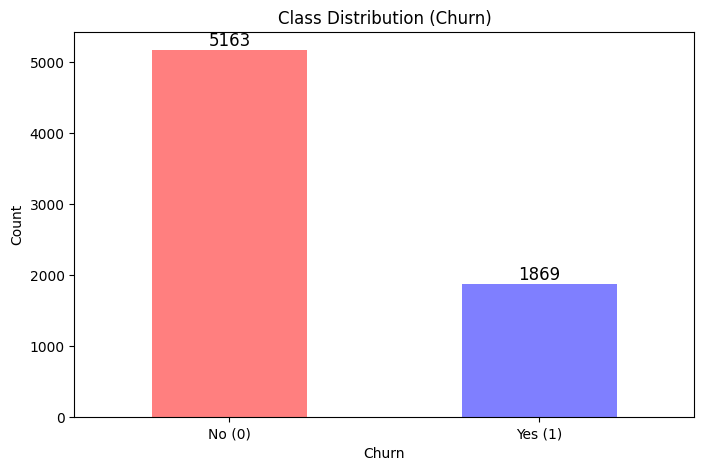

In [399]:
# Class distribution
plt.figure(figsize=(8, 5))
ax = df['Churn'].value_counts().plot(kind='bar', color=['red', 'blue'], alpha=0.5)
plt.title('Class Distribution (Churn)')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.xticks([0, 1], ['No (0)', 'Yes (1)'], rotation=0)

# Добавляем значения на бары
for p in ax.patches:
    ax.text(p.get_x() + p.get_width()/2, p.get_height() + 10, int(p.get_height()), 
            ha='center', va='bottom', fontsize=12)

plt.savefig('./pictures/classes.png', dpi=300, bbox_inches='tight')
plt.show()

In [400]:
# define data
X = df.drop(['customerID', 'Churn'], axis=1)
y = df['Churn'].astype(int)

In [401]:
print(f'Number of duplicated rows in X: {X.duplicated().sum()}')

Number of duplicated rows in X: 40


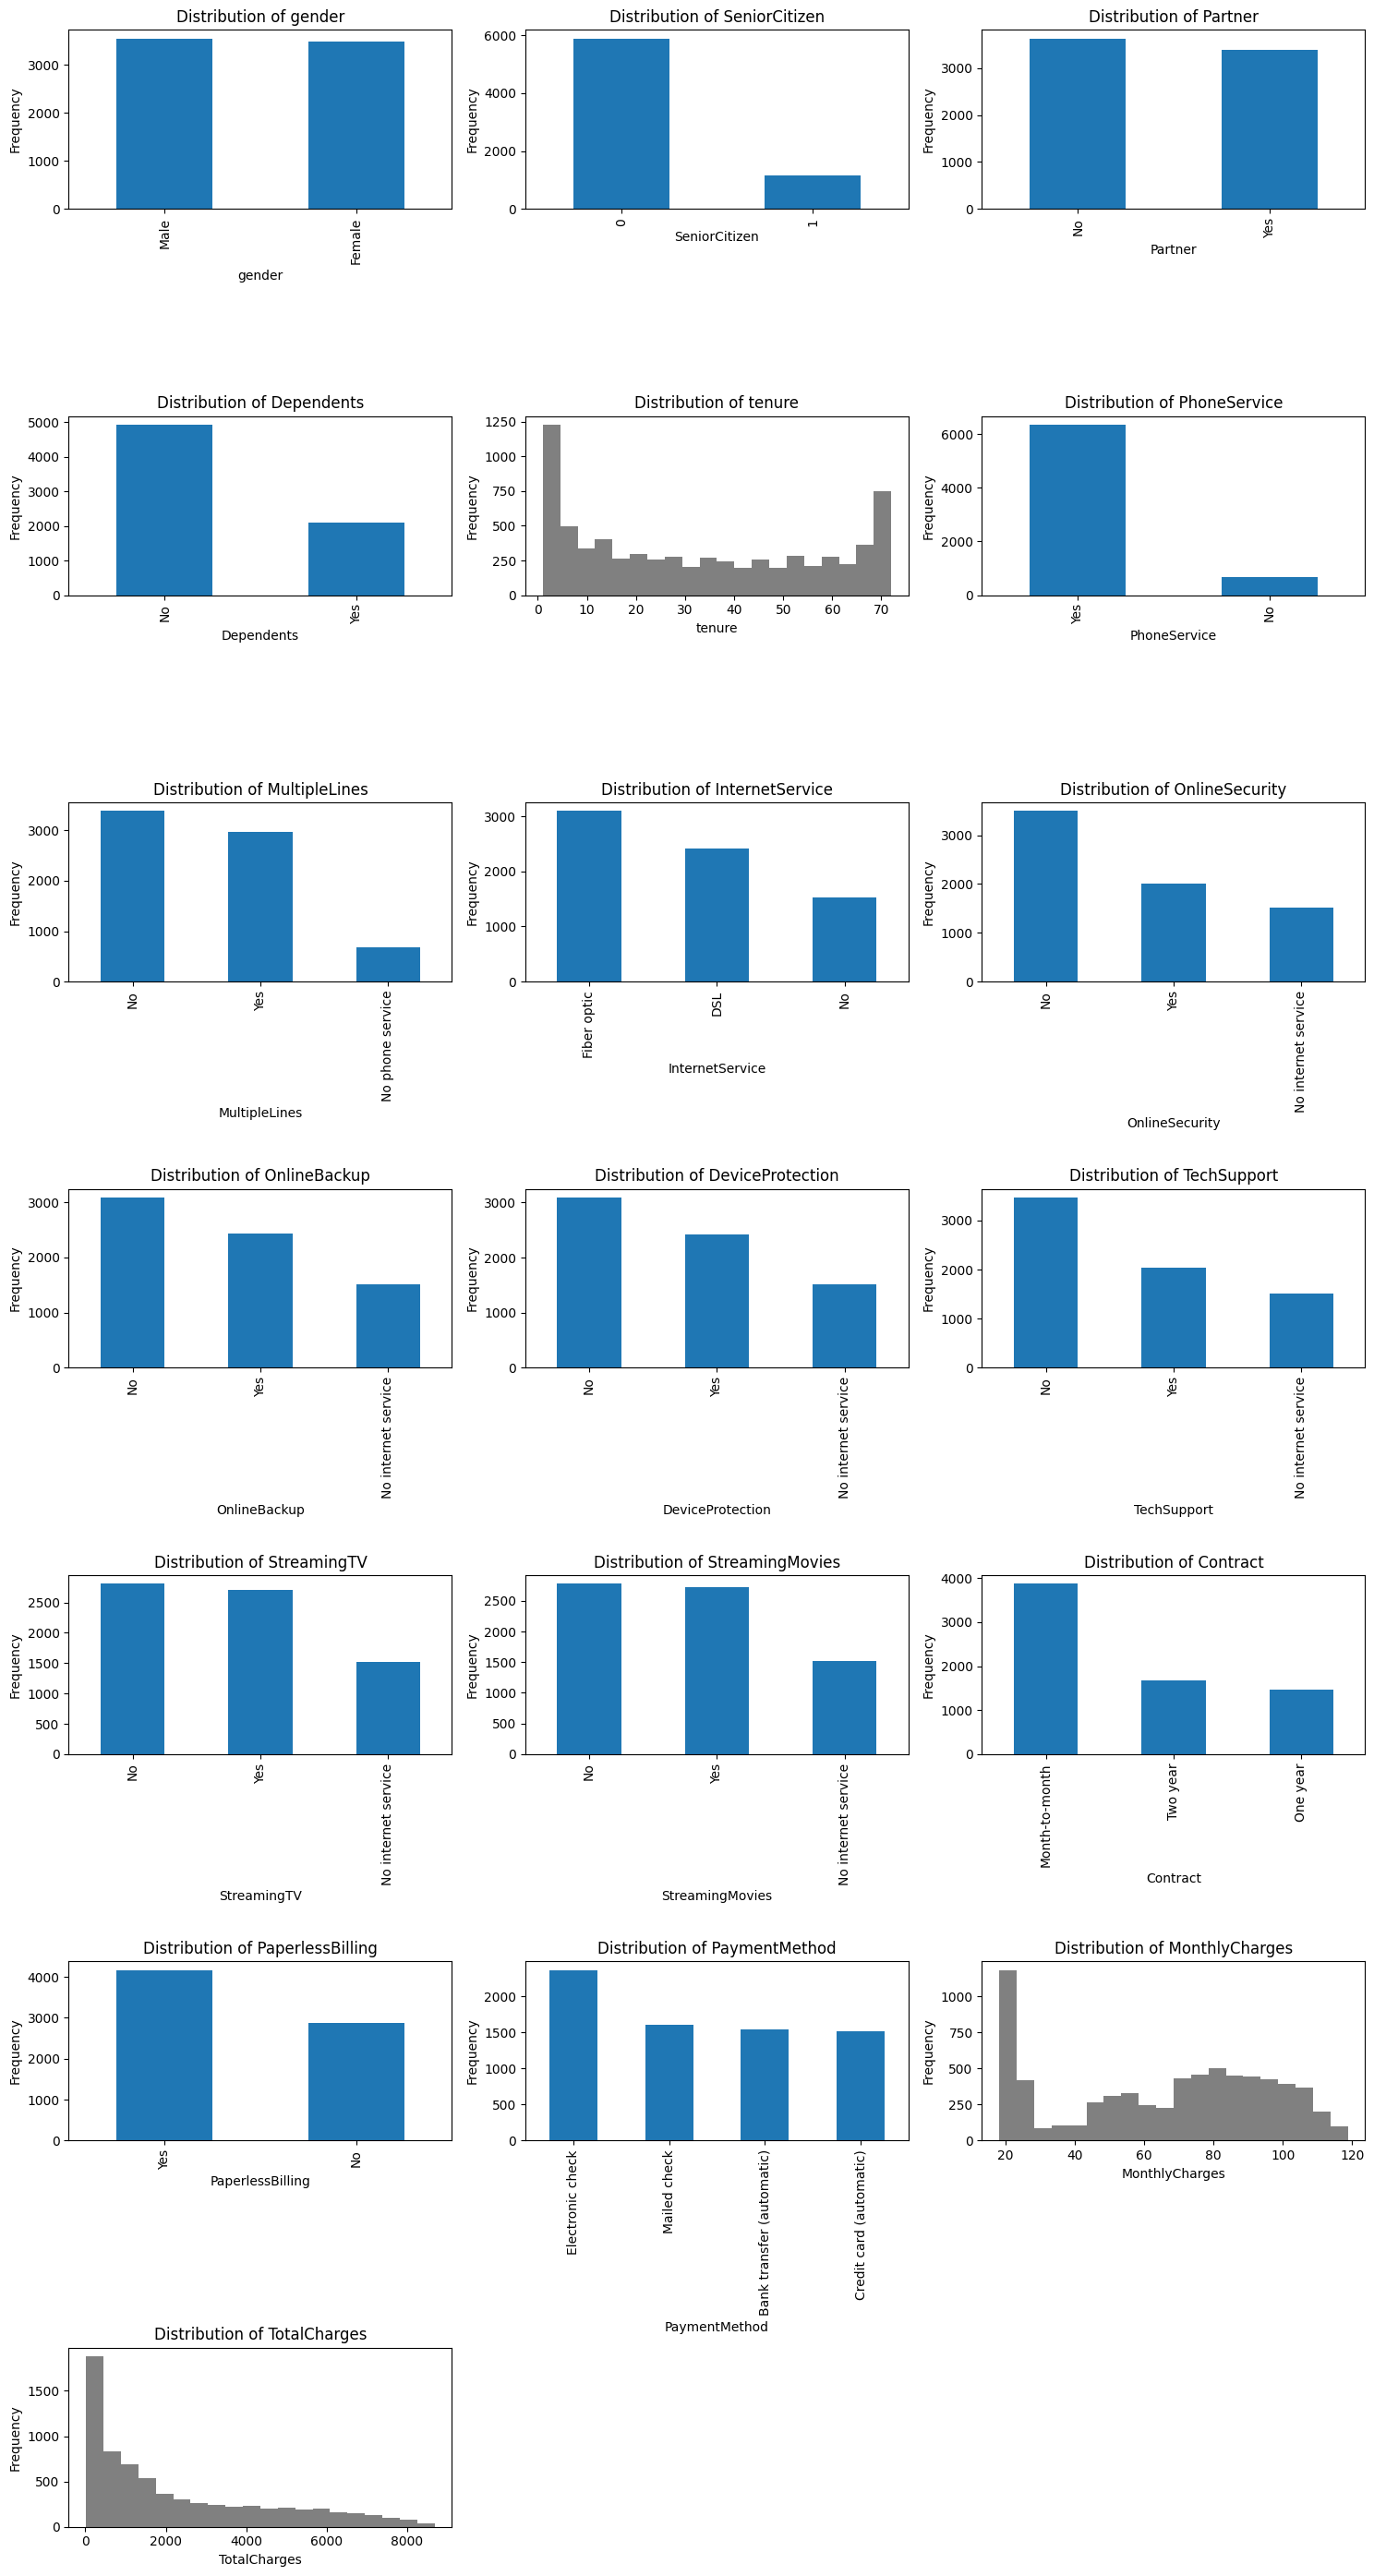

In [402]:
num_columns = len(X.columns)
cols = 3
rows = math.ceil(num_columns / cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 4))
axes = axes.flatten()

for i, column in enumerate(X.columns):
    ax = axes[i]
    if X[column].dtype == 'object' or len(X[column].unique()) < 20:
        # For categorical or discrete features, use a bar plot
        X[column].value_counts().plot(kind='bar', ax=ax)
        ax.set_title(f'Distribution of {column}')
        ax.set_xlabel(column)
        ax.set_ylabel('Frequency')
    else:
        # For continuous features, use a histogram
        X[column].plot(kind='hist', bins=20, ax=ax, color='gray')
        ax.set_title(f'Distribution of {column}')
        ax.set_xlabel(column)
        ax.set_ylabel('Frequency')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

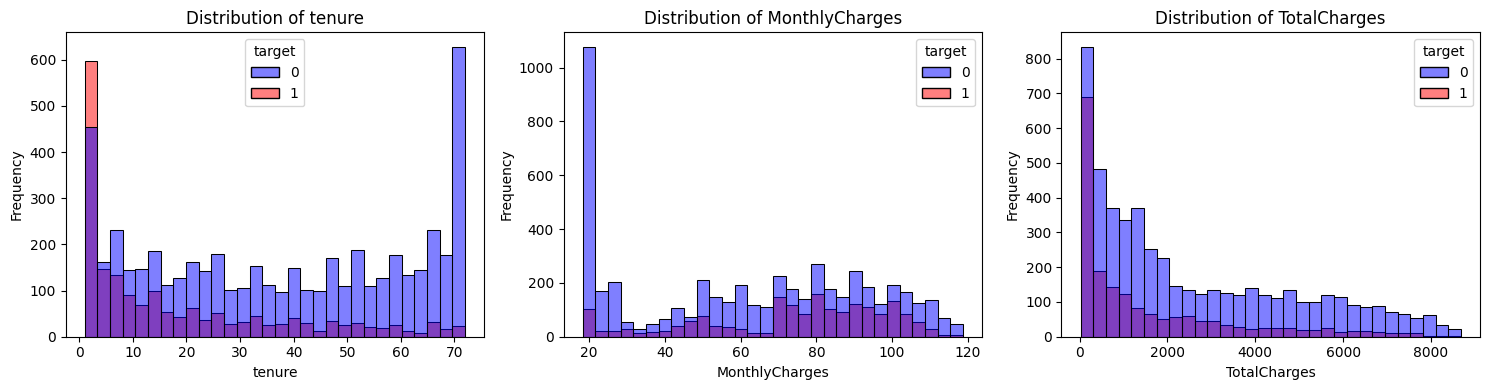

In [403]:
X_plot = X.drop(columns=['SeniorCitizen'], errors='ignore')
X_num = X_plot.select_dtypes(exclude=['object'])

num_columns = len(X_num.columns)
cols = 3
rows = math.ceil(num_columns / cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 4))
axes = axes.flatten()

y_plot = y
if not hasattr(y, 'name') or y.name is None:
    y_plot = pd.Series(y, name='target')

for i, column in enumerate(X_num.columns):
    ax = axes[i]
    sns.histplot(
        data=X_num.assign(target=y_plot),
        x=column, hue="target",
        bins=30,
        palette={0: 'blue', 1: 'red'},
        multiple='layer',
        ax=ax,
        alpha=0.5
    )
    ax.set_title(f'Distribution of {column}')
    ax.set_xlabel(column)
    ax.set_ylabel('Frequency')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('./pictures/dist_num.png', dpi=300, bbox_inches='tight')
plt.show()


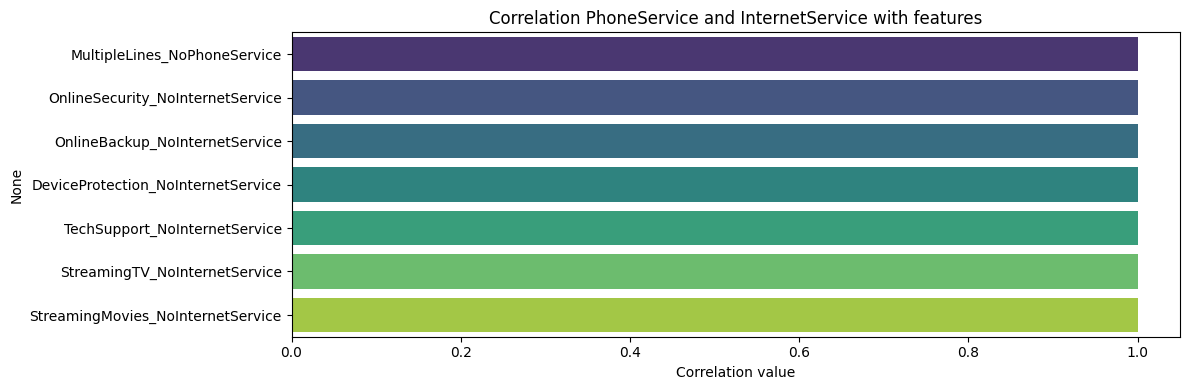

In [404]:
cols_to_check = [
    'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]

ph_mask = (X['PhoneService'] == 'No').astype(int)
ml_mask = (X['MultipleLines'] == 'No phone service').astype(int)
corr1 = np.corrcoef(ph_mask, ml_mask)[0,1]

int_mask = (X['InternetService'] == 'No').astype(int)
corr_list = []
feat_names = ['MultipleLines_NoPhoneService']

for col in cols_to_check[1:]:
    feat_mask = (X[col] == 'No internet service').astype(int)
    corr = np.corrcoef(int_mask, feat_mask)[0,1]
    corr_list.append(corr)
    feat_names.append(f'{col}_NoInternetService')

all_corrs = [corr1] + corr_list
feat_names = [feat_names[0]] + feat_names[1:]

corr_df = pd.Series(all_corrs, index=feat_names)

plt.figure(figsize=(12,4))
sns.barplot(x=corr_df.values, y=corr_df.index, palette='viridis')
plt.title('Correlation PhoneService and InternetService with features')
plt.xlabel('Correlation value')
plt.tight_layout()
plt.savefig('./pictures/corr_no.png', dpi=300, bbox_inches='tight')
plt.show()


In [405]:
cols_to_replace = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
df[cols_to_replace] = df[cols_to_replace].replace(['No phone service', 'No internet service'], 'No')

X = df.drop(['customerID', 'Churn'], axis=1)
y = df['Churn'].astype(int)

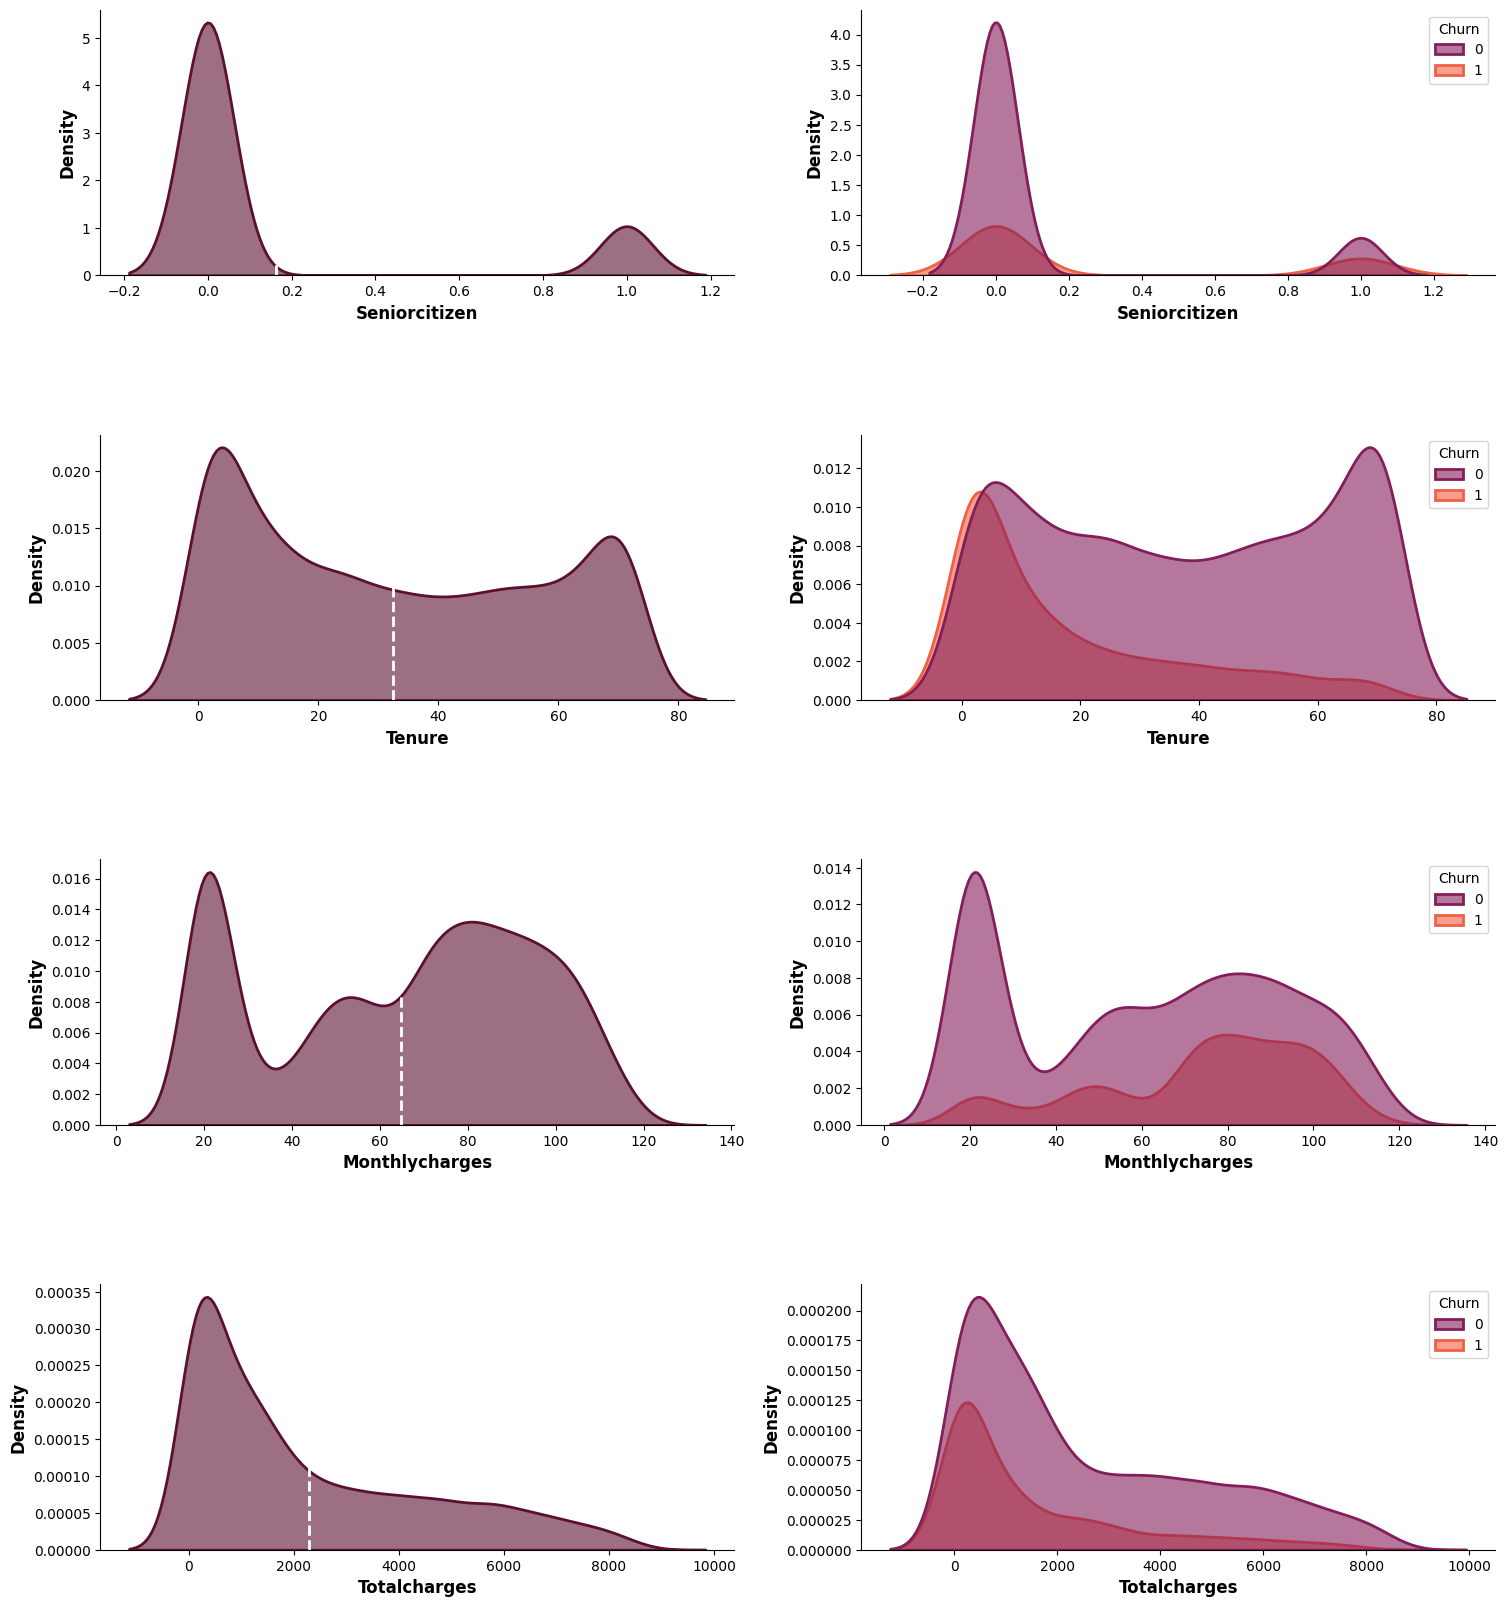

In [406]:
# Get only numeric columns
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

plotIndex = 1
plt.figure(figsize=(18, 5 * len(numeric_cols)))
for col in numeric_cols:
    plt.subplot(len(numeric_cols), 2, plotIndex)
    sns.kdeplot(data=X, x=col, fill=True, linewidth=2, color='#5c1031', alpha=0.6)
    plt.axvline(X[col].mean(), color='white', linestyle='--', linewidth=2)
    plt.xlabel(xlabel=col.title(), fontsize=12, weight='bold')
    plt.ylabel(ylabel='Density', fontsize=12, weight='bold')
    sns.despine()

    plt.subplot(len(numeric_cols), 2, plotIndex + 1)
    sns.kdeplot(data=X, x=col, fill=True, hue=y, linewidth=2, palette='rocket', alpha=0.6)
    plt.xlabel(xlabel=col.title(), fontsize=12, weight='bold')
    plt.ylabel(ylabel='Density', fontsize=12, weight='bold')
    sns.despine()

    plotIndex += 2

plt.subplots_adjust(hspace=0.6)
plt.savefig('./pictures/kde_numeric_columns.png', dpi=300, bbox_inches='tight')
plt.show()

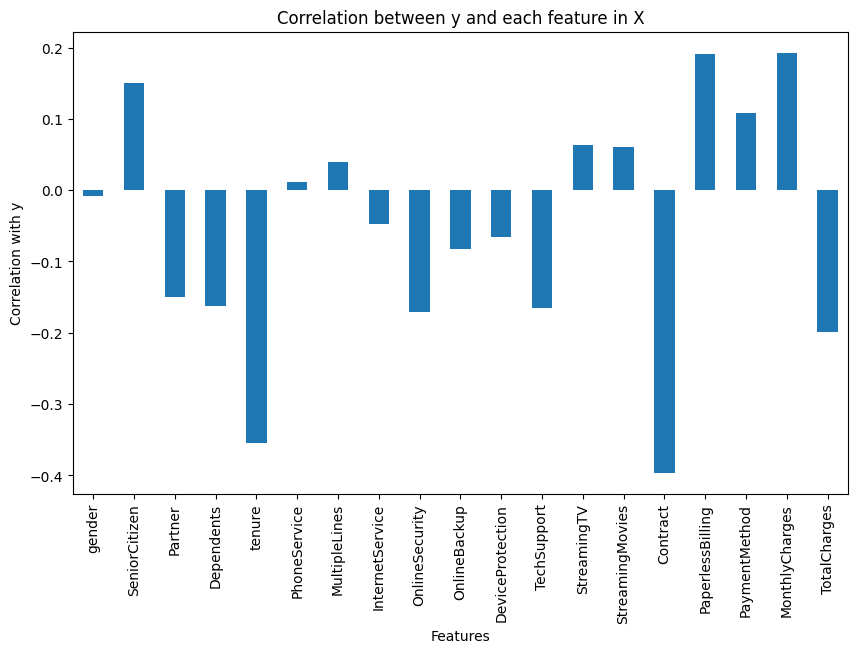

In [407]:
# correlations
X_encoded = X.copy()
for col in X.select_dtypes(include=['object', 'category']).columns:
    X_encoded[col] = X[col].astype('category').cat.codes
correlations = X_encoded.corrwith(y)
correlations.plot(kind='bar', figsize=(10, 6))
plt.title('Correlation between y and each feature in X')
plt.xlabel('Features')
plt.ylabel('Correlation with y')
plt.show()

In [408]:
df.to_csv('eda_churn.csv', index=False)